In [2]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import xarray as xr
import  scipy
import pickle
import matplotlib.pyplot as plt
import sys
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.colors as mcolors
sys.path.append("../") 
import WRFDomainLib
plt.rcParams["font.family"] = "Sans-Serif"


def cmap_white(vmin=-1, vmax=6, cmap='plasma_r'):
    # Number of discrete levels
    n_levels = (vmax - vmin) + 1

    # Get reversed plasma colormap with discrete steps
    inferno = cm.get_cmap(cmap, n_levels)

    # Sample discrete colors
    colors = [inferno(i / (n_levels - 1)) for i in range(n_levels)]

    # Replace the first color with white
    colors[0] = (1, 1, 1, 1)  # RGBA for white

    # Create a discrete colormap
    return mcolors.ListedColormap(colors, name="cmap_white")

#cmap = plasma_white()#inferno_white()


mpl.rcParams['hatch.linewidth'] = 0.1
mpl.rcParams['patch.edgecolor']='none'
WPSFile = '/gpfs/fs7/dfo/hpcmc/pfm/spfm000/CanESM2-WRF/plotting_files/namelist.wps.txt'
wpsproj, latlonproj, corner_lat_full, corner_lon_full, length_x, length_y = WRFDomainLib.calc_wps_domain_info(WPSFile)




ERROR 1: PROJ: proj_create_from_database: Open of /home/amh001/space_fs7/software_2022/python/py_2024/share/proj failed


In [3]:
def loadseason(season,path0,period,mytype):
    file0=path0+f''+mytype+'_'+period+'_'+season.lower()+'_yearly.nc'
    ds = xr.open_dataset(file0)
    counts = ds["count"].values
    lat = ds["lat"].values
    lon=ds['lon'].values
    return counts, lat, lon
   

In [4]:
types=['colddry', 'warmdry', 'warmwet', 'coldwet']

seasons= ["DJF", "MAM", "JJA", "SON"];
path0='/gpfs/fs7/dfo/hpcmc/pfm/amh001/DATA/WRF/CompoundCounts/'
def loadandsort(mytype):
    season_data={}
    for season in seasons:
        data,lat,lon=loadseason(season,path0, 'hist', mytype)
        season_data[season] = data
    
    season_data_rcp45={}
    for season in seasons:
        data, lat, lon=loadseason(season,path0, 'rcp45', mytype)
        season_data_rcp45[season] = data
    data={}
    for season in seasons:
        data[season]=np.mean(season_data[season], axis=0)
        data['pval_'+season]= scipy.stats.ttest_ind(season_data[season], season_data_rcp45[season])[1]
        data['F_'+season]=np.mean(season_data_rcp45[season], axis=0)
    return data, lat, lon

In [5]:
colddry, lat, lon=loadandsort('cold_dry')

In [6]:
warmdry, lat, lon=loadandsort('warm_dry')
coldwet, lat, lon=loadandsort('cold_wet')
warmwet, lat, lon=loadandsort('warm_wet')

In [7]:
print(len(colddry['pval_'+'DJF']))

300


In [8]:

#mpl.rcParams['hatch.color'] = 'gray'
def plotseasons(j, count, season_data, axes, seasons, nmodels, var):
#j=0
#count=0
    vmin=vlims[var][0];vmax=vlims[var][1]
    #print(vmin, vmax)
    for i, season in enumerate(seasons):
        ax = axes[i, j] if nmodels > 1 else axes[i]
        field = season_data[season][0]
        pval  = season_data[season][1]
        #print('D3 pvals', np.amax(pval), np.amin(pval))
        # Main colormap
        #print(vmin, vmax)
        mesh = ax.pcolormesh(
            lon, lat, field,
            cmap=var_cmaps[var], vmin=vmin,vmax=vmax,
            transform=ccrs.PlateCarree()    )
        #meshes.append(mesh)
    
        
        cs = ax.contourf(
            lon, lat, pval,
            levels=[0.1, 1],
            colors="none", 
            hatches=[hatch_pattern],  # pass as a list
            transform=ccrs.PlateCarree()
        )
        coastline = cf.COASTLINE.with_scale('10m')
        ax.add_feature(coastline, linewidth=0.1, edgecolor='black')

    
        ax.text(at, bt, subpanel[count], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
        if j==0:
            ax.text(-0.18, 0.6, season, transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
        #ax.text(.6, 1.1,'D3' , transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
        ax.set_extent([-129.6, -120.15, 46.4, 51.7], crs=ccrs.PlateCarree())
        
        count+=1

    if i == len(seasons) - 1:  # After last row in the column
        # Get position of the bottom axis in the column
        bbox = ax.get_position()
        # Create a new axis below it for the colorbar
        cbar_ax = fig.add_axes([
            bbox.x0, bbox.y0 - 0.03,  # slightly below the bottom subplot
            bbox.width, 0.015         # same width, small height
        ])
        cbar = fig.colorbar(mesh, cax=cbar_ax, extend='both', orientation="horizontal")
        cbar.set_label(label[var], fontsize=10)
        cbar.set_ticks([vmin,(vmax-abs(vmin))/2,vmax])
    return count

In [9]:
def plotdata(data, val):
    #print('val n funct', val)
    ax.set_extent([-129.6, -120.15, 46.4, 51.7], crs=ccrs.PlateCarree())
    coastline = cf.COASTLINE.with_scale('10m')
    ax.add_feature(coastline, linewidth=0.1, edgecolor='black')
    if j == 0:  # historical
        field = data[row_labels[i]]
        cmap='Blues'
        vmin=0;vmax=12
    else:
        field = data['F_'+row_labels[i]]
        mask = data['pval_'+row_labels[i]] <0.1
        cmap='PRGn'
        vmin=-val; vmax=val 
        
                
        cs = ax.contourf(
            lon, lat, ~mask,
            levels=[0.1,1],
            colors="none", 
            hatches=['...'],  # pass as a list
            transform=ccrs.PlateCarree(), zorder=10
        )
        
      
    mesh = ax.pcolormesh(
    lon, lat, field,
    cmap=cmap ,
    vmin=vmin,vmax=vmax,
    transform=ccrs.PlateCarree()    )

   
    
    #else:       # mid-century - historical
     #   diff = data_mid[i, j] - data_hist[i, j]
      #  im = ax.pcolormesh(Lon, Lat, diff,
       #                    cmap=cmap_diff, vmin=vmin_diff, vmax=vmax_diff,
        #                   transform=ccrs.PlateCarree())
    
    # Hide tick labels for clarity
    ax.set_xticks([])
    ax.set_yticks([])
    if i==1:
        bbox = ax.get_position()
    # Create a new axis below it for the colorbar
        cbar_ax = fig.add_axes([
            bbox.x0, bbox.y0 - 0.03,  # slightly below the bottom subplot
            bbox.width, 0.01         # same width, small height
        ])
        cbar = fig.colorbar(mesh, cax=cbar_ax, extend='both', orientation="horizontal")
        cbar.set_label(labels[j], fontsize=8)
        cbar.set_ticks([vmin,(vmax-abs(vmin))/2,vmax])
#plt.tight_layout()

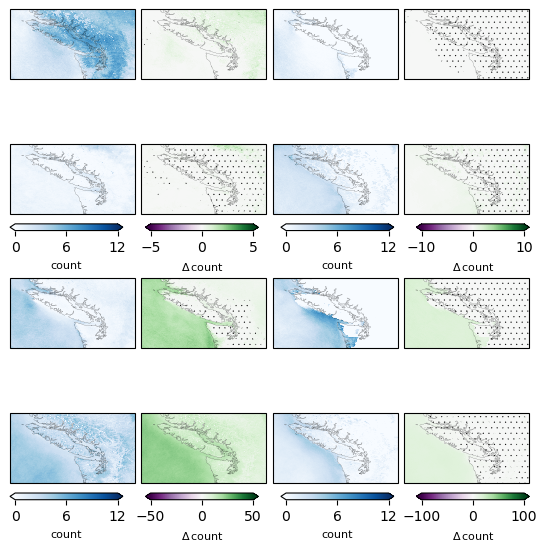

In [10]:
fig, axes = plt.subplots(4, 4, figsize=(6.7,6.7),
                         subplot_kw={'projection': ccrs.PlateCarree()})

col_titles = ["Historical", "Mid-Century"]
row_labels = ["JJA", "DJF"]

vvals={'coldwet': 5, 'warmwet':50, 'warmdry': 100, 'colddry':10}
labels=['count', r'$\Delta\, \mathrm{count}$']
for i in range(2):          # seasons: JJA, DJF
    for j in range(2):
        ax = axes[i, j]   # careful indexing
        var='coldwet'
        data = eval(var)
        val=vvals[var];
        #print(val)
        plotdata(data, val)
        var='warmwet'
        data = eval(var)
        val=vvals[var];

        ax=axes[i+2,j]
        plotdata(data, val)
        
        var='warmdry'
        data = eval(var)
        val=vvals[var];

        ax=axes[i+2,j+2]
        plotdata(data, val)

        var='colddry'
        data = eval(var)
        val=vvals[var];

        ax=axes[i,j+2]
        plotdata(data, val)
        
plt.subplots_adjust(hspace=0.2, wspace=0.05) 

In [11]:
def plotdata(data, val, count, var):
    #print('val n funct', val)
    data = eval(var)
    val=vvals[var];
    
    if j == 0:  # historical
        field = data[row_labels[i]]
        cmap=cmap_white(0,countmax)#'inferno'
        vmin=0;vmax=countmax
        label0='Events/y'
        #plt.title('historical')
    else:
        field = data['F_'+row_labels[i]]
        mask = data['pval_'+row_labels[i]] <0.1
        cmap=cmaps[var]
        vmin=-val; vmax=val 
        label0=r'$\Delta$Events/y'
        #plt.title('$\Delta$')
        
                
        cs = ax.contourf(
            lon, lat, ~mask,
            levels=[0.1,1],
            colors="none", 
            hatches=hatches,  # pass as a list
            transform=ccrs.PlateCarree(), zorder=10
        )
        
      
    mesh = ax.pcolormesh(
    lon, lat, field,
    cmap=cmap ,
    vmin=vmin,vmax=vmax,
    transform=ccrs.PlateCarree()    )

    ax.set_extent([-129.6, -120.10, 46.4, 51.7], crs=ccrs.PlateCarree())
    coastline = cf.COASTLINE.with_scale('10m')
    ax.add_feature(coastline, linewidth=0.1, edgecolor='black')
    
    #else:       # mid-century - historical
     #   diff = data_mid[i, j] - data_hist[i, j]
      #  im = ax.pcolormesh(Lon, Lat, diff,
       #                    cmap=cmap_diff, vmin=vmin_diff, vmax=vmax_diff,
        #                   transform=ccrs.PlateCarree())
    
    # Hide tick labels for clarity
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(at, bt, subpanel[count], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000)
    count+=1
    #print('count', count)
    if i==1:
    # Example: add colorbar under row i=1
        bbox = ax.get_position()
        cbar_ax = fig.add_axes([
            bbox.x0+0.02, bbox.y0 - 0.02,  # leave a bigger gap
            bbox.width-0.04, 0.012     # 
        ])
        if j ==0:   
            cbar = fig.colorbar(mesh, cax=cbar_ax, extend='max', orientation="horizontal")
        else:
            cbar = fig.colorbar(mesh, cax=cbar_ax, extend='both', orientation="horizontal")

        cbar.set_label(label0, fontsize=8,labelpad=1)
        cbar.set_ticks([vmin,(vmax-abs(vmin))/2,vmax])
        cbar.ax.tick_params(labelsize=8)
    return count
#plt.tight_layout()

/tmp/amh001/1085/ipykernel_1294/2228411228.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  inferno = cm.get_cmap(cmap, n_levels)
/tmp/amh001/1085/ipykernel_1294/2228411228.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  inferno = cm.get_cmap(cmap, n_levels)
/tmp/amh001/1085/ipykernel_1294/2228411228.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  inferno = cm.get_cmap(cmap, n_levels)
/tmp/amh001/1085/ipykernel_1294/2228411228.py:24: MatplotlibDepr

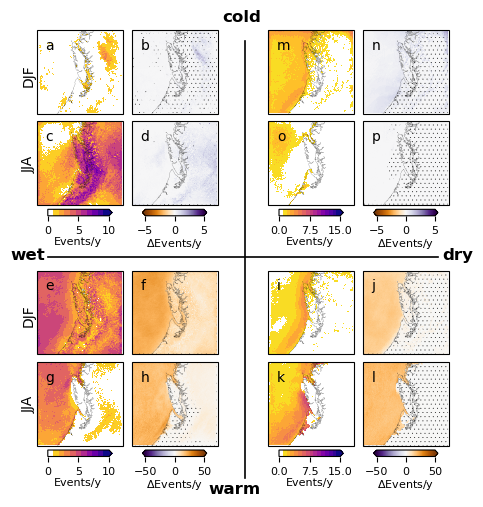

In [15]:
import matplotlib.gridspec as gridspec
dense_dots = "." * 2  # repeat the dot
hatches = [dense_dots + " " + dense_dots]

row_labels = ["DJF", "JJA"]
nrows = 4
ncols = 4
sublist=['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o','p', 'q', 'r', 's', 't', 'u']
# Reshape and transpose
subpanel = np.array(sublist[:nrows * ncols]).reshape(nrows, ncols).T.flatten().tolist()

at=0.1;bt=0.9
vvals={'coldwet': 5, 'warmwet':50, 'warmdry': 50, 'colddry':5}
labels=['count', r'$\Delta\, \mathrm{count}$']
cmaps={'coldwet': 'PuOr', 'warmwet':'PuOr_r', 'warmdry': 'PuOr_r', 'colddry':'PuOr'}

fig = plt.figure(figsize=(5.4,5.4))

gs = gridspec.GridSpec(
    5, 5, figure=fig,
    height_ratios=[1, 1, 0.6, 1, 1],   # colorbar row is short
    width_ratios=[1, 1, 0.43, 1, 1],    # middle spacer col is narrow
    hspace=0.1, wspace=0.025
)

axes = np.empty((4,4), dtype=object)

# Fill rows 0 and 1 (top half)
for i in range(2):
    for j in range(2):  # left block
        axes[i,j] = fig.add_subplot(gs[i, j], projection=wpsproj)
    for j in range(2,4):  # right block
        axes[i,j] = fig.add_subplot(gs[i, j+1], projection=wpsproj)

# Fill rows 3 and 4 (bottom half)
for i in range(2):
    for j in range(2):  # left block
        axes[i+2,j] = fig.add_subplot(gs[i+3, j], projection=wpsproj)
    for j in range(2,4):  # right block
        axes[i+2,j] = fig.add_subplot(gs[i+3, j+1], projection=wpsproj)

count=0
for i in range(2):          # seasons: JJA, DJF
    for j in range(2):
        ax = axes[i, j]   # careful indexing
        countmax=10
        var='coldwet'
        data = eval(var)
        val=vvals[var];

        if j==0: #upper left
            ax.text(-0.18, 0.6, row_labels[i], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')
        #print(val)
        count=plotdata(data, val,count, var)
        #plotdata(data, val)
        var='warmwet'
        ax=axes[i+2,j]
        count=plotdata(data, val,count, var)
        if j==0:
            ax.text(-0.18, 0.6, row_labels[i], transform=ax.transAxes,  va='top', fontweight='normal',zorder=1000, rotation='vertical')        
        countmax=15
        var='warmdry'
        
        ax=axes[i+2,j+2]
        #plotdata(data, val)
        count=plotdata(data, val,count, var)
        var='colddry'
        ax=axes[i,j+2]
        count=plotdata(data, val,count, var)


# Vertical divider: between left and right panels
# --- Top half vertical divider ---
x_div = axes[0,1].get_position().x1 +0.05  # right edge of left block

y1_top = axes[0,0].get_position().y1 # top of row 0 (first row)


# --- Bottom half vertical divider ---
y0_bot = 0#axes[3,0].get_position().y0  # bottom of row 3


fig.add_artist(plt.Line2D([x_div, x_div], [y0_bot+0.05, y1_top-0.02],
                          transform=fig.transFigure, color="black", lw=1.2))
# Horizontal divider: between top and bottom panels
# Take x-limits from the leftmost and rightmost panels in that row
x0 = axes[0,0].get_position().x0   # left edge of far-left panel
x1 = axes[0,3].get_position().x1   # right edge of far-right panel
y_div = axes[2,0].get_position().y1+0.025 # top of bottom block
fig.add_artist(plt.Line2D([x0+0.02, x1-0.02], [y_div, y_div],
                          transform=fig.transFigure, color="black", lw=1.2))

# Cold label (left of vertical line, top)
fig.text(x_div+0.03 , y1_top+0.01, "cold", ha="right", va="bottom", fontsize=12, fontweight="bold")
# Warm label (right of vertical line, bottom)
fig.text(x_div+0.03 , y0_bot+0.015, "warm", ha="right", va="bottom", fontsize=12, fontweight="bold")


# Wet label (left of horizontal line, top)
fig.text(x0-0.05, y_div-0.01 , "wet", ha="left", va="bottom", fontsize=12, fontweight="bold")
# Dry label (right of horizontal line, bottom)
fig.text(x1+0.045, y_div-0.01, "dry", ha="right", va="bottom", fontsize=12, fontweight="bold")
plt.savefig('CompoundEvents.png', format='png', bbox_inches='tight',transparent=False,dpi=500)